<a href="https://colab.research.google.com/github/amanmd07/2520030190_ML/blob/master/PROJECT/crop_yield_test_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np

In [21]:
import pandas as pd
import seaborn as sns

In [22]:
# Load the crop yield dataset
from pandas import read_csv
df=read_csv("/content/crop_yield_test.csv")


In [23]:
# Numerical vs Categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object', 'category', 'bool']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']
Categorical Features: ['State', 'Crop', 'Season']


In [24]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

In [25]:
# Print matrix to terminal
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
                     Year      Area  Production  Annual_Rainfall  Fertilizer  \
Year             1.000000 -0.016646   -0.000014         0.054014    0.018033   
Area            -0.016646  1.000000    0.042126        -0.153940    0.928011   
Production      -0.000014  0.042126    1.000000         0.024507    0.043410   
Annual_Rainfall  0.054014 -0.153940    0.024507         1.000000   -0.123979   
Fertilizer       0.018033  0.928011    0.043410        -0.123979    1.000000   
Pesticide        0.016366  0.922644    0.041204        -0.120377    0.982152   
Yield            0.009588  0.002268    0.595345         0.026966    0.006276   

                 Pesticide     Yield  
Year              0.016366  0.009588  
Area              0.922644  0.002268  
Production        0.041204  0.595345  
Annual_Rainfall  -0.120377  0.026966  
Fertilizer        0.982152  0.006276  
Pesticide         1.000000  0.005166  
Yield             0.005166  1.000000  


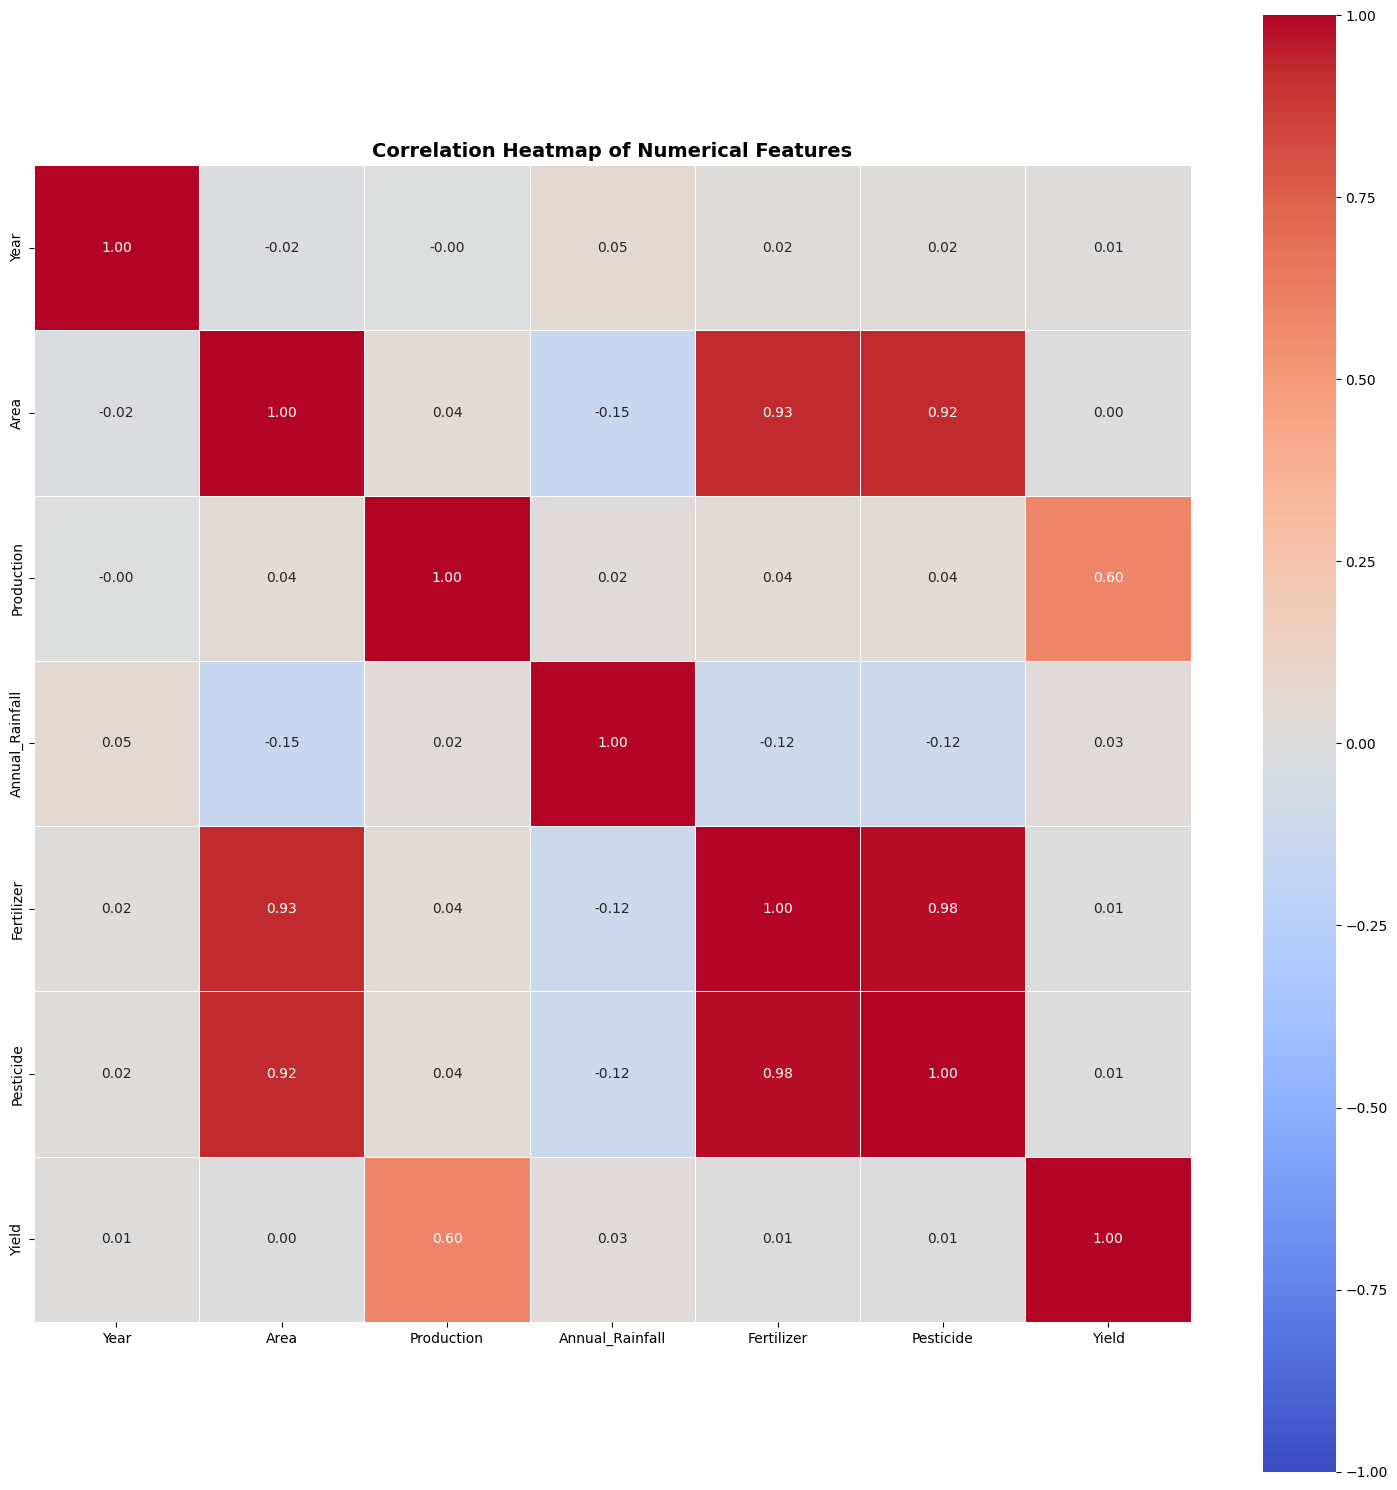

In [26]:
# Create Heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

In [27]:

# Export Heatmap
import os
output_dir = "/content/"
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: /content/correlation_heatmap.png


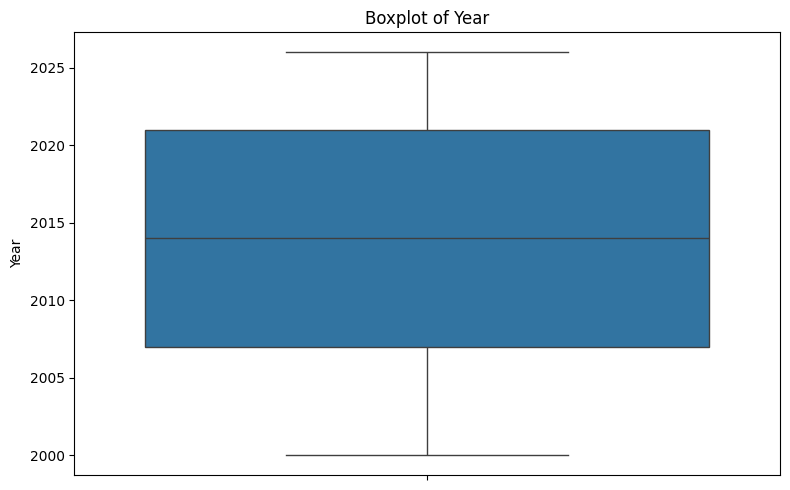

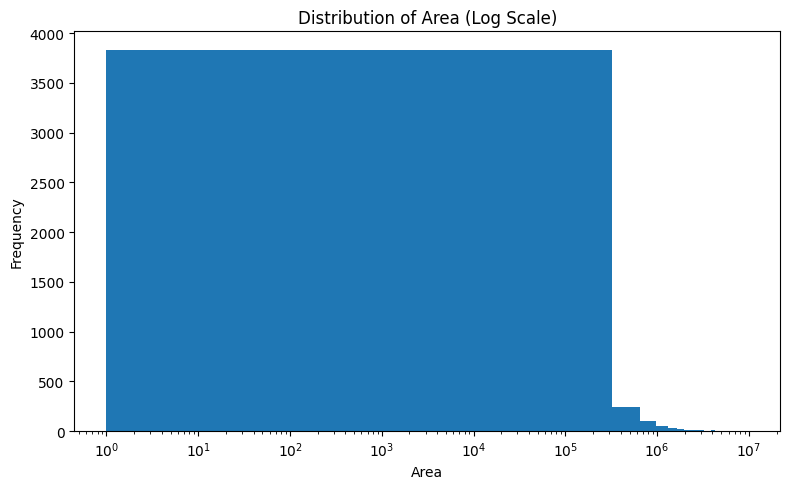

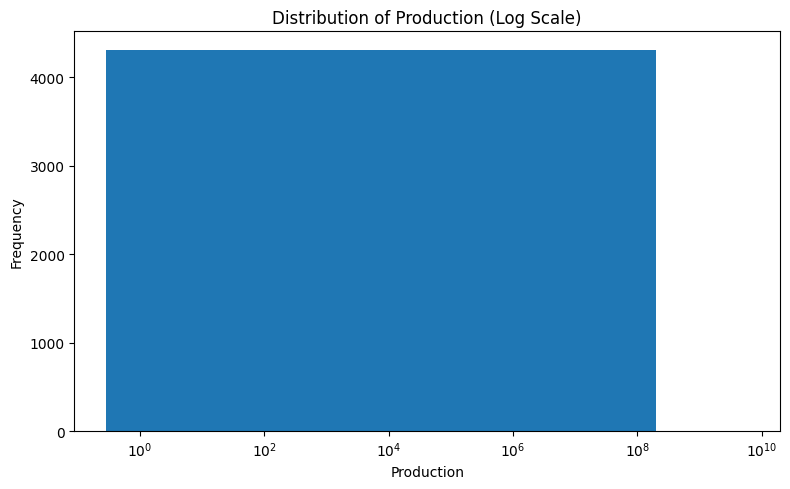

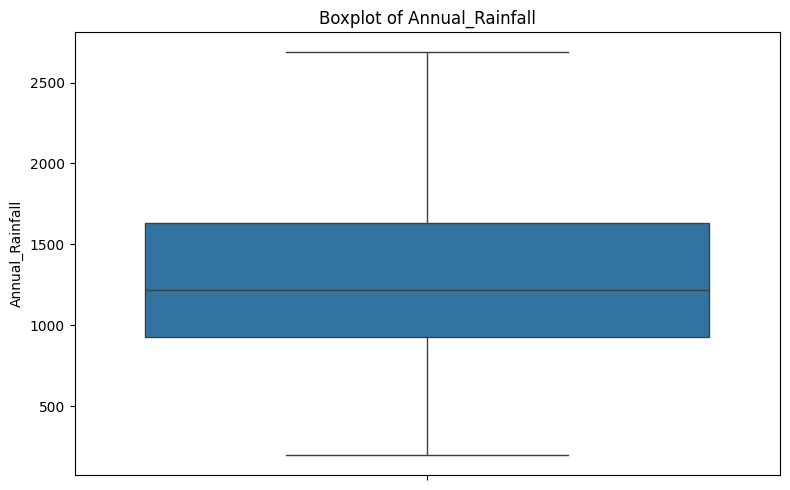

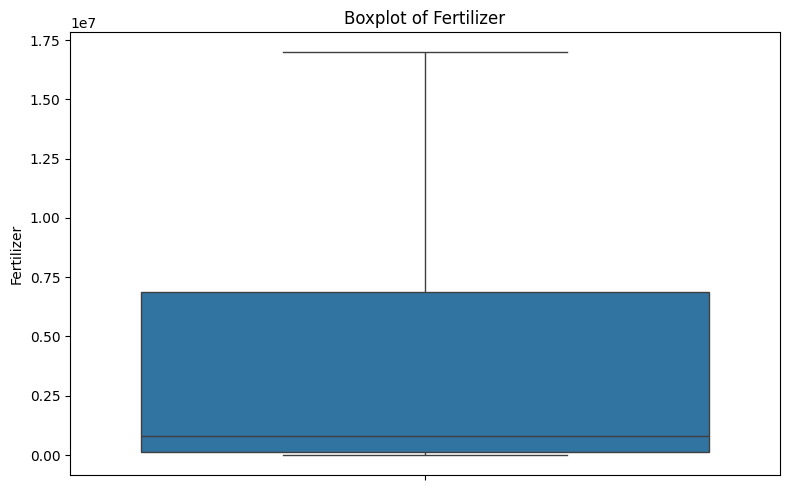

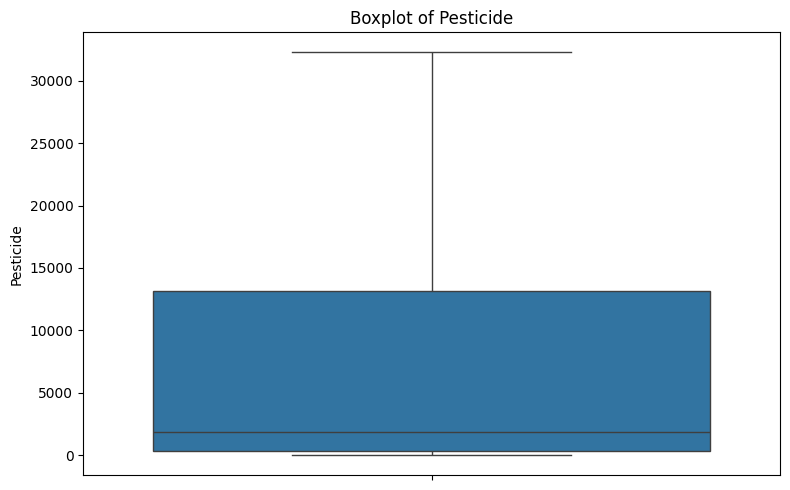

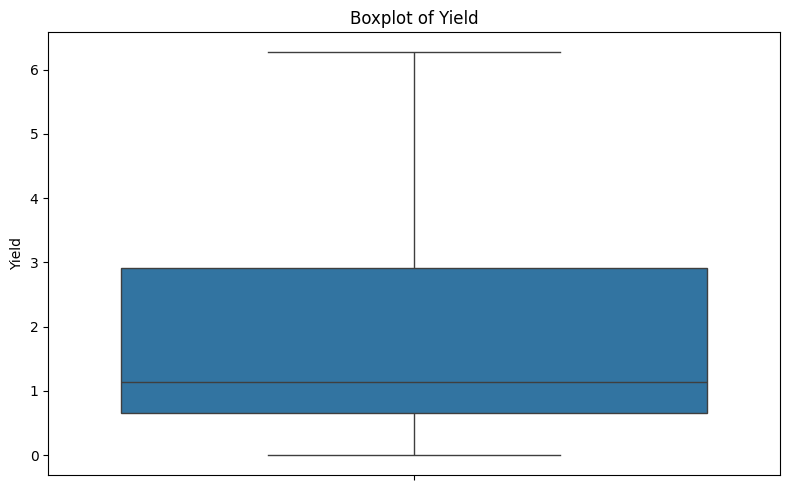

In [28]:
# Distribution graphs for numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numerical_cols:
    # Use a boxplot for compact-range variables such as Year.
    # Use a log-scaled histogram for highly skewed variables such as Area and Production.
    if col in ['Area', 'Production']:
        plt.figure(figsize=(8, 5))
        values = df[col].dropna()
        values = values[values > 0]
        plt.hist(values, bins=30)
        plt.xscale('log')
        plt.title(f'Distribution of {col} (Log Scale)')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(8, 5))
        sns.boxplot(y=df[col], showfliers=False)
        plt.title(f'Boxplot of {col}')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

Missing Values:
Year               0
State              0
Crop               0
Season             0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64


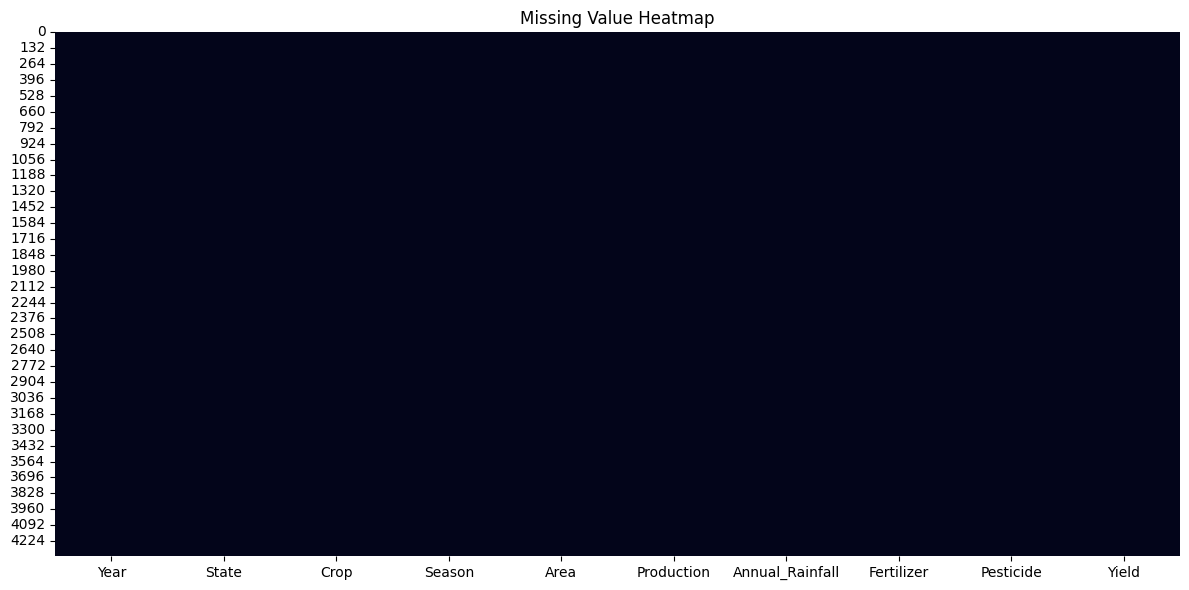

In [29]:
# Missing value analysis
print("Missing Values:")
print(df.isnull().sum())

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Value Heatmap')
plt.tight_layout()
plt.show()

<Figure size 1500x800 with 0 Axes>

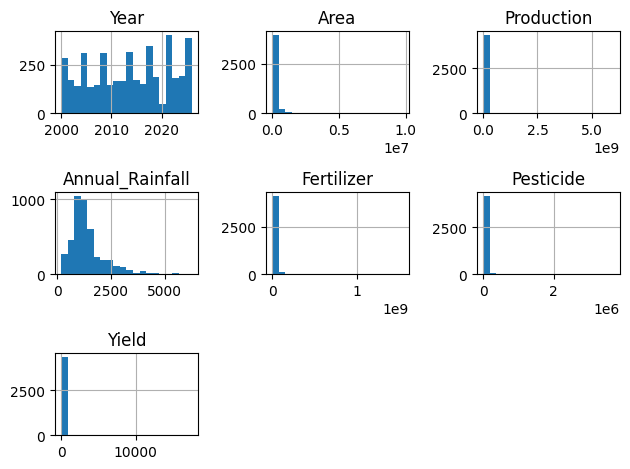

In [30]:
features = ['Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']

fig2=plt.figure(figsize=(15,8))
df[features].hist(
    bins=20
)

plt.tight_layout()

plt.show()

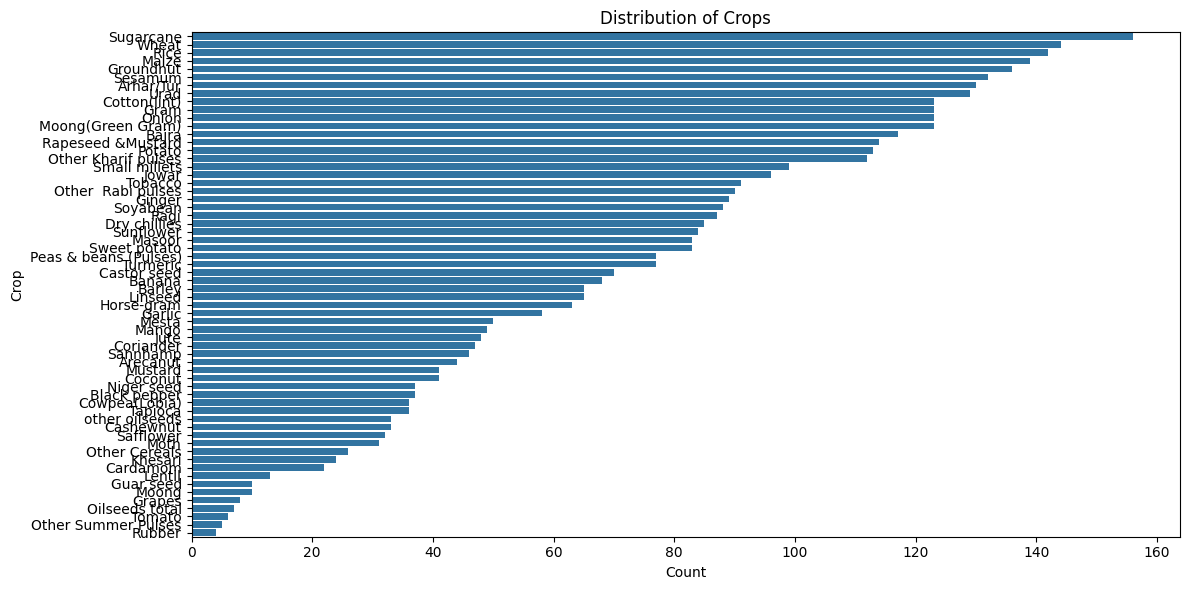

In [31]:
# Distribution of Crops

fig3=plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Crop",
    order=df['Crop'].value_counts().index
)

plt.title("Distribution of Crops")
plt.xlabel("Count")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

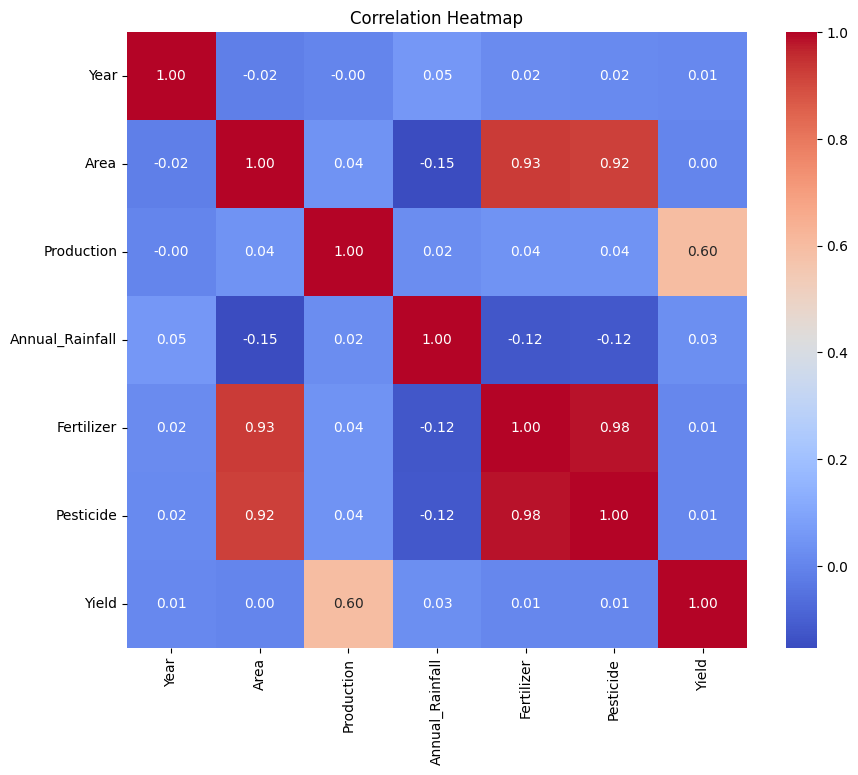

In [32]:
#Corelation Heatmap

fig5= plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

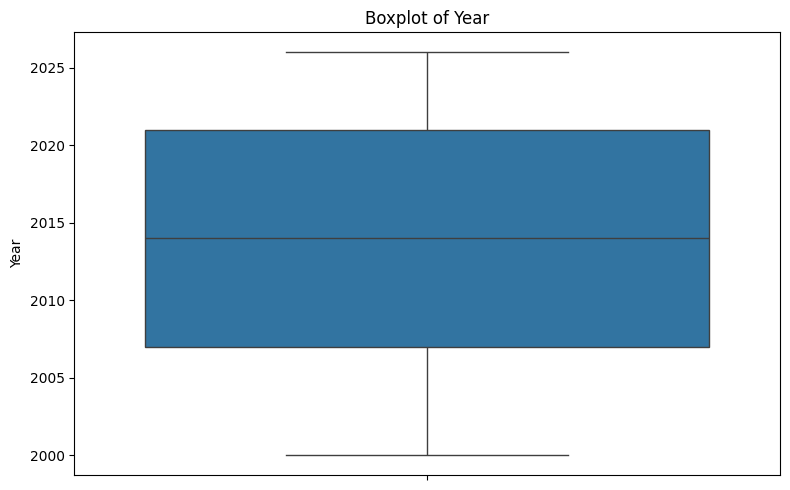

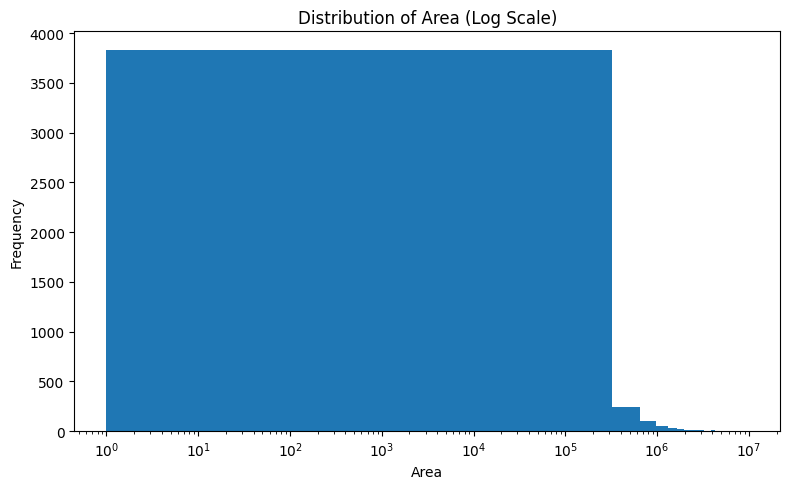

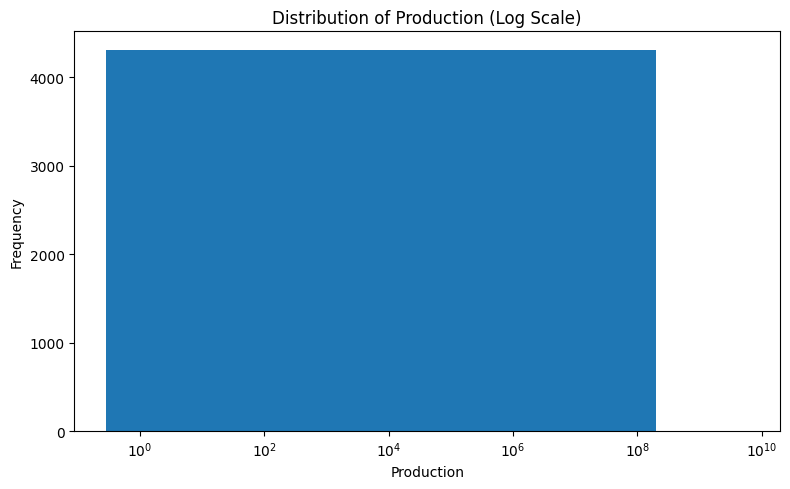

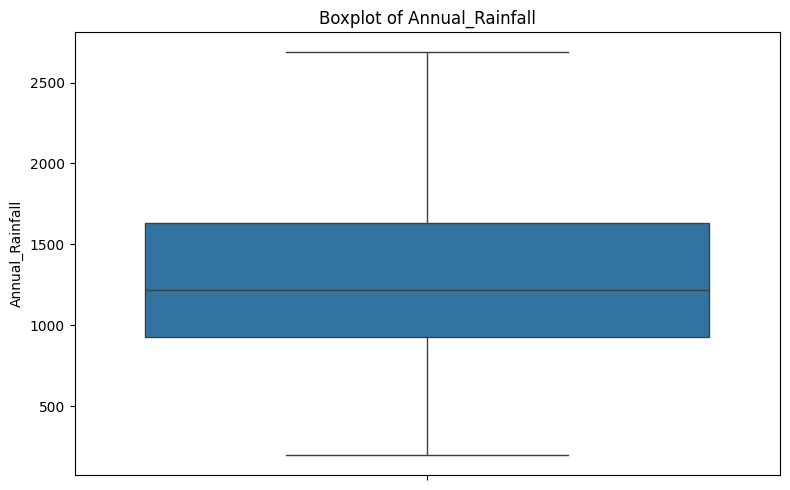

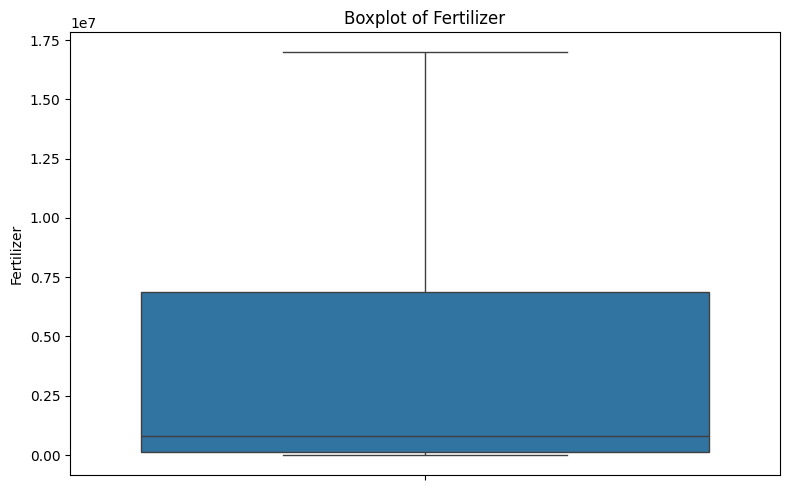

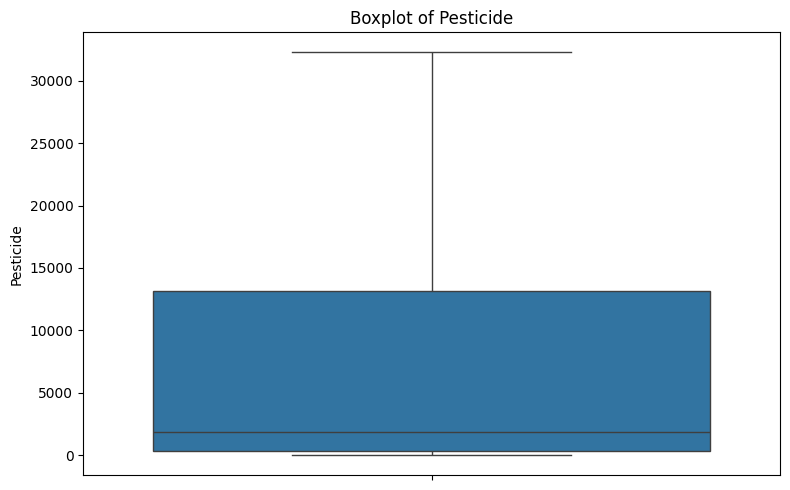

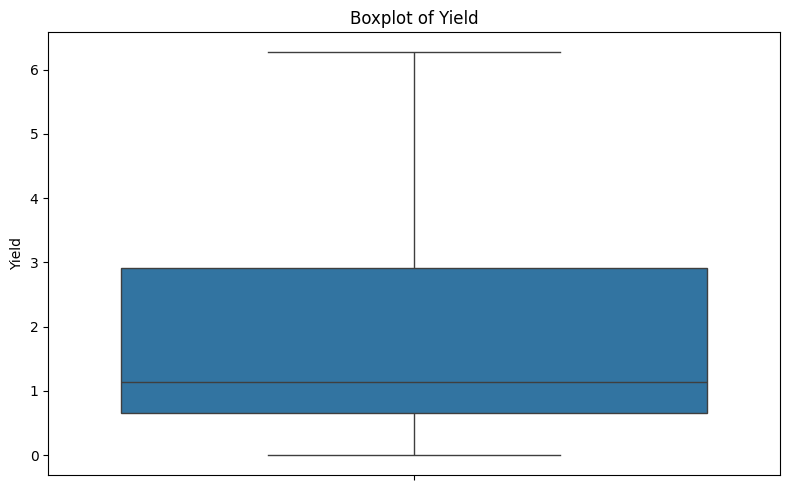

In [33]:
# Distribution graphs for numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numerical_cols:
    # Use a boxplot for compact-range variables such as Year.
    # Use a log-scaled histogram for highly skewed variables such as Area and Production.
    if col in ['Area', 'Production']:
        plt.figure(figsize=(8, 5))
        values = df[col].dropna()
        values = values[values > 0]
        plt.hist(values, bins=30)
        plt.xscale('log')
        plt.title(f'Distribution of {col} (Log Scale)')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(8, 5))
        sns.boxplot(y=df[col], showfliers=False)
        plt.title(f'Boxplot of {col}')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

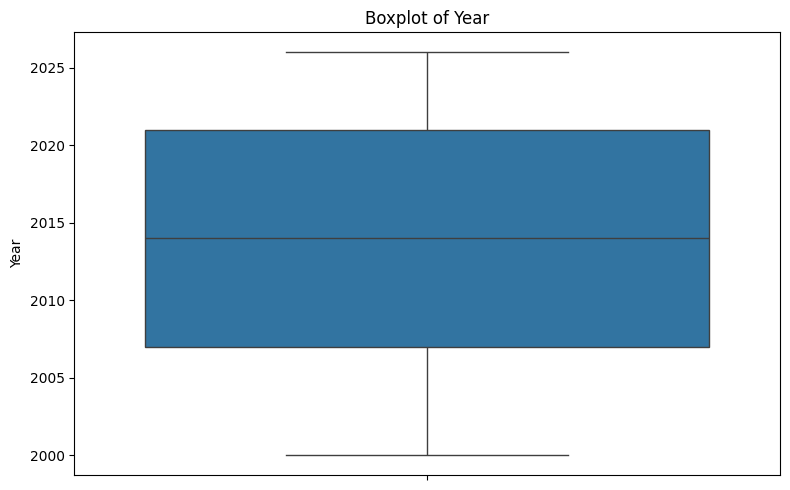

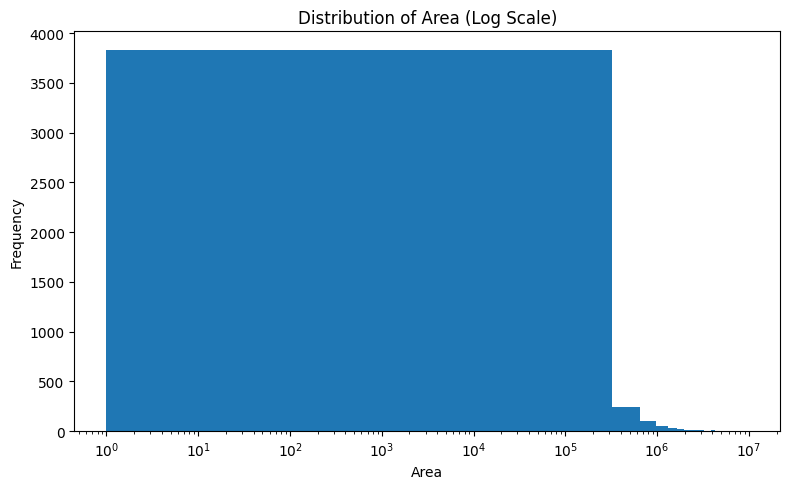

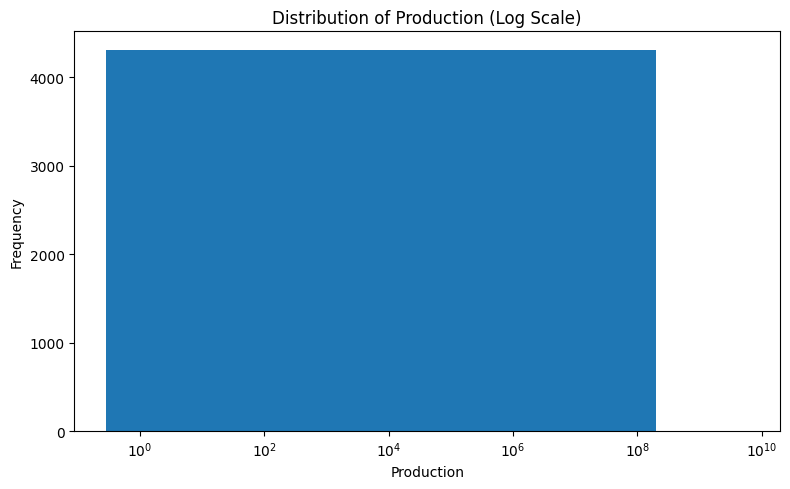

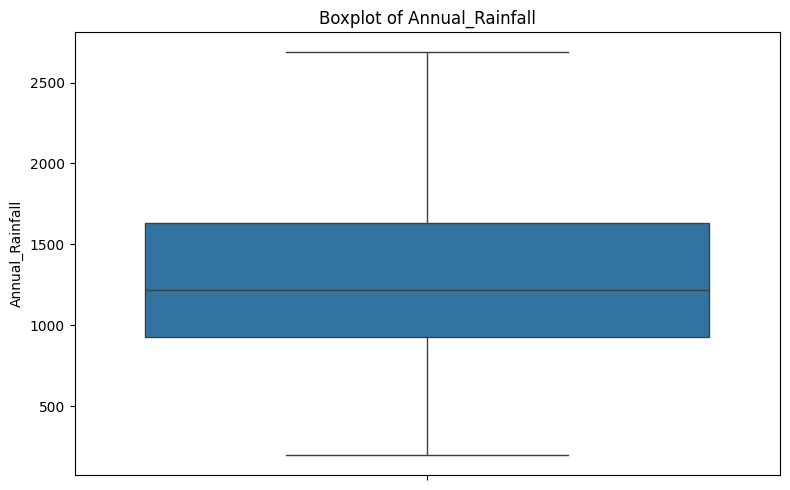

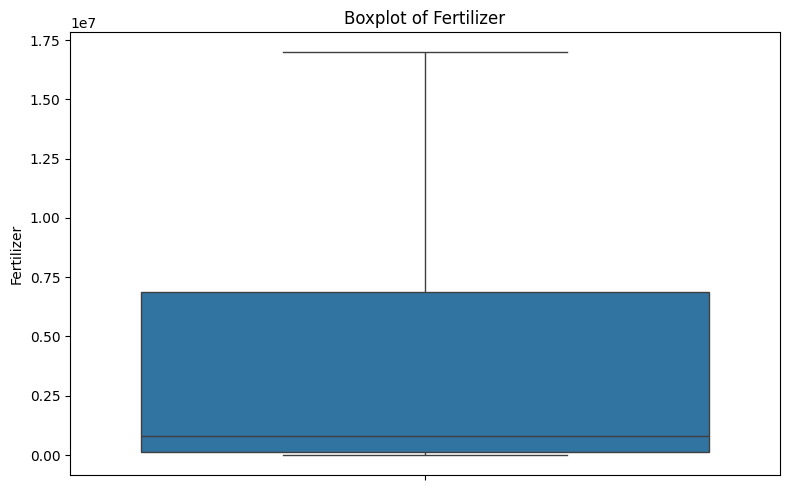

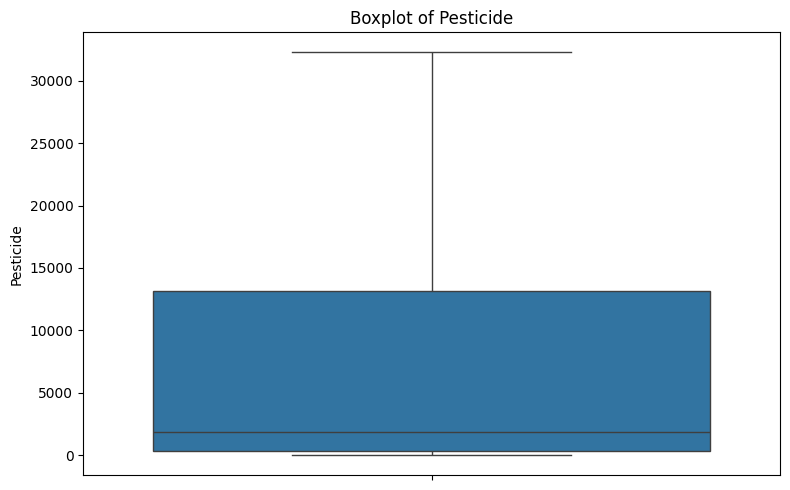

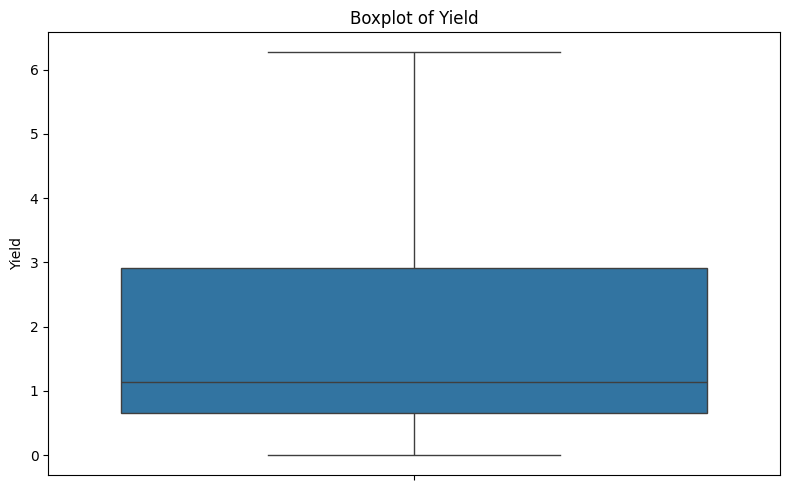

In [34]:
# Distribution graphs for numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numerical_cols:
    # Use a boxplot for compact-range variables such as Year.
    # Use a log-scaled histogram for highly skewed variables such as Area and Production.
    if col in ['Area', 'Production']:
        plt.figure(figsize=(8, 5))
        values = df[col].dropna()
        values = values[values > 0]
        plt.hist(values, bins=30)
        plt.xscale('log')
        plt.title(f'Distribution of {col} (Log Scale)')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(8, 5))
        sns.boxplot(y=df[col], showfliers=False)
        plt.title(f'Boxplot of {col}')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

In [35]:
# Save the EDA report as PDF
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages('EDA_Report.pdf') as pdf:
    fig = plt.figure(figsize=(12, 6))
    sns.heatmap(df.isnull(), cbar=False)
    plt.title('Missing Value Heatmap')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    fig = plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

print('EDA_Report.pdf created successfully.')

EDA_Report.pdf created successfully.
